Loaded 125 labels.

Loading ONNX model...

Running inference using submission.preprocess_data()
Scanning: C:\Users\kartp\OneDrive\Documentos\IFRoS\1st semester\Machine Learning\Labs\FP\test
Elements inside directory: ['arrays', 'labels.csv']
Test dataset: 125
arr.max() > 1.0 and arr.max() <= 255
arr.max() > 1.0 and arr.max() <= 255
arr.max() > 1.0 and arr.max() <= 255
arr.max() > 1.0 and arr.max() <= 255
arr.max() > 1.0 and arr.max() <= 255
arr.max() > 1.0 and arr.max() <= 255
arr.max() > 1.0 and arr.max() <= 255
arr.max() > 1.0 and arr.max() <= 255
arr.max() > 1.0 and arr.max() <= 255
arr.max() > 1.0 and arr.max() <= 255
arr.max() > 1.0 and arr.max() <= 255
arr.max() > 1.0 and arr.max() <= 255
arr.max() > 1.0 and arr.max() <= 255
arr.max() > 1.0 and arr.max() <= 255
arr.max() > 1.0 and arr.max() <= 255
arr.max() > 1.0 and arr.max() <= 255
arr.max() > 1.0 and arr.max() <= 255
arr.max() > 1.0 and arr.max() <= 255
arr.max() > 1.0 and arr.max() <= 255
arr.max() > 1.0 and arr.max() <= 255


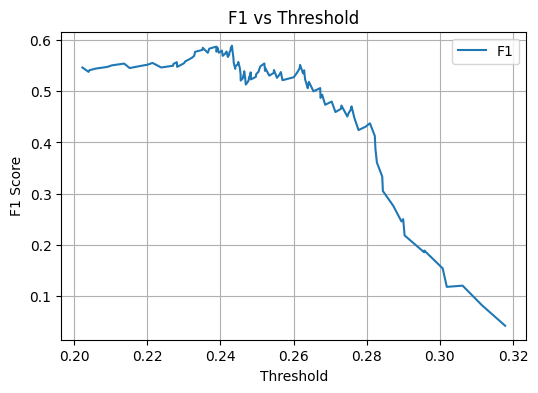

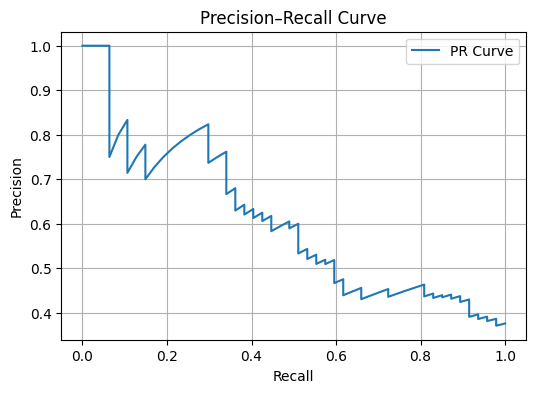

In [ ]:
import numpy as np
import onnxruntime as ort
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score, precision_recall_curve

# MODEL_PATH  = r"C:\Users\kartp\OneDrive\Documentos\IFRoS\1st semester\Machine Learning\Labs\FP\model10\model10.onnx"
MODEL_PATH  = r"C:\Users\kartp\OneDrive\Documentos\IFRoS\1st semester\Machine Learning\Labs\FP\model12\model.onnx"
IMAGES_DIR  = r"C:\Users\kartp\OneDrive\Documentos\IFRoS\1st semester\Machine Learning\Labs\FP\test"
LABELS_CSV  = r"C:\Users\kartp\OneDrive\Documentos\IFRoS\1st semester\Machine Learning\Labs\FP\test\labels.csv"

# Import submission functions
import submission

def load_labels(csv_path):
    label_dict = {}
    with open(csv_path, "r") as f:
        for i, line in enumerate(f):
            if i == 0: continue  # skip header
            prefix, label = line.strip().split(",")
            label_dict[prefix] = int(label)
    return label_dict

def main():

    # Load labels
    labels = load_labels(LABELS_CSV)
    print(f"Loaded {len(labels)} labels.\n") # It has to be 1380

    # Load ONNX model using submission.py
    print("Loading ONNX model...")
    model = submission.load_model(MODEL_PATH)

    # Prepare arrays
    all_true = []
    all_scores = []

    # Use EXACT preprocessing from submission.py
    print("\nRunning inference using submission.preprocess_data()")
    for file_prefix, input_tensor in submission.preprocess_data(IMAGES_DIR):
        if file_prefix not in labels:
            print(f"WARNING: Missing label for {file_prefix}, skipping.")
            continue
        
        # Predictions
        y_true = labels[file_prefix]
        y_pred = submission.run_inference(model, input_tensor)

        # Stores the predictions
        all_true.append(y_true)
        all_scores.append(y_pred)

    all_true = np.array(all_true)
    all_scores = np.array(all_scores)

    # --------------------------------------------------
    # Compute AUCPR
    # --------------------------------------------------
    aucpr = average_precision_score(all_true, all_scores)
    print(f"\nAUCPR (local ONNX evaluation) = {aucpr:.4f}")

    # --------------------------------------------------
    # Compute best F1
    # --------------------------------------------------
    precisions, recalls, thresholds = precision_recall_curve(all_true, all_scores)

    f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-12)
    best_idx = np.argmax(f1_scores)
    best_f1 = f1_scores[best_idx]

    # thresholds array is len(f1_scores) - 1
    best_threshold = thresholds[max(best_idx - 1, 0)]

    print(f"Best F1 = {best_f1:.4f} at threshold {best_threshold:.4f}\n")

    # --------------------------------------------------
    # Plot F1 curve
    # --------------------------------------------------
    plt.figure(figsize=(6, 4))
    plt.plot(thresholds, f1_scores[:-1], label="F1")
    plt.xlabel("Threshold")
    plt.ylabel("F1 Score")
    plt.title("F1 vs Threshold")
    plt.grid(True)
    plt.legend()
    plt.show()

    # --------------------------------------------------
    # Plot PR curve
    # --------------------------------------------------
    plt.figure(figsize=(6, 4))
    plt.plot(recalls, precisions, label="PR Curve")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision–Recall Curve")
    plt.grid(True)
    plt.legend()
    plt.show()


if __name__ == "__main__":
    main()

In [2]:
import os

test_dir = os.path.join(IMAGES_DIR, "arrays", "002_025_10.npy")
x = np.load(test_dir)
print("min:", x.min(), "max:", x.max(), "dtype:", x.dtype)


min: 1.0 max: 255.0 dtype: float64
